In [17]:
# import packages
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib
import statsmodels
print("All good!")

All good!


In [18]:
# Basic imports
import pandas as pd
import numpy as np

# Stats & models
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Plots
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('./remote_work_productivity_modified.csv')
df.head()

,Employee_ID,Employment_Type,Hours_Worked_Per_Week,Productivity_Score,Well_Being_Score
0,1,Hybrid,29,75,78
1,2,In-Office,45,49,47
2,3,Hybrid,34,74,89
3,4,Remote,25,81,84
4,5,Remote,50,70,74


In [20]:
# Standardize Employment_Type text
df['Employment_Type'] = df['Employment_Type'].astype(str).str.strip().str.title()
df['Employment_Type'] = df['Employment_Type'].replace({
    'In Office': 'In-Office',
    'In-Office': 'In-Office',
    'Inoffice': 'In-Office',
    'Remote': 'Remote',
    'Work From Home': 'Remote',
    'Wfh': 'Remote',
    'Hybrid': 'Hybrid'
})

# Confirm categories and counts
print(df['Employment_Type'].value_counts())

Employment_Type
In-Office    510
Remote       404
Hybrid        86
Name: count, dtype: int64


In [21]:
# Missing values
print('Missing values per column:\n', df.isnull().sum())

# If small number of missing values, drop; else impute with median for numeric
# Example strategy:
num_cols = ['Hours_Worked_Per_Week','Productivity_Score','Well_Being_Score']
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# If any Employment_Type missing, drop those rows (rare)
df = df[~df['Employment_Type'].isin(['nan','None','NoneType'])]

Missing values per column:
 Employee_ID              0
Employment_Type          0
Hours_Worked_Per_Week    0
Productivity_Score       0
Well_Being_Score         0
dtype: int64


In [22]:
# Ensure ranges are sensible
df = df[(df['Hours_Worked_Per_Week'] >= 0) & (df['Hours_Worked_Per_Week'] <= 100)]
df = df[(df['Productivity_Score'] >= 0) & (df['Productivity_Score'] <= 100)]
df = df[(df['Well_Being_Score'] >= 0) & (df['Well_Being_Score'] <= 100)]

# Final counts
print('Final sample size:', len(df))
df['Employment_Type'].value_counts()

Final sample size: 985


,count
Employment_Type,
In-Office,509
Remote,390
Hybrid,86


In [23]:
group_summary = df.groupby('Employment_Type').agg(
    N=('Employee_ID','count'),
    Mean_Productivity=('Productivity_Score','mean'),
    SD_Productivity=('Productivity_Score','std'),
    Mean_Hours=('Hours_Worked_Per_Week','mean'),
    SD_Hours=('Hours_Worked_Per_Week','std'),
    Mean_WellBeing=('Well_Being_Score','mean'),
    SD_WellBeing=('Well_Being_Score','std')
).reset_index()
group_summary

,Employment_Type,N,Mean_Productivity,SD_Productivity,Mean_Hours,SD_Hours,Mean_WellBeing,SD_WellBeing
0,Hybrid,86,71.348837,11.925028,34.860465,6.911479,70.186047,8.208334
1,In-Office,509,63.789784,9.840510,44.430255,5.927843,58.583497,14.717129
2,Remote,390,73.007692,11.263721,34.820513,6.985743,69.443590,10.508689


**Focused Comparison: Remote vs In-Office**

In [24]:
remote = df[df['Employment_Type'] == 'Remote']['Productivity_Score']
office = df[df['Employment_Type'] == 'In-Office']['Productivity_Score']

remote.head()
office.head()

,Productivity_Score
1,49
5,66
9,59
14,76
16,73


In [25]:
remote = df[df['Employment_Type'] == 'Remote']['Productivity_Score']
office = df[df['Employment_Type'] == 'In-Office']['Productivity_Score']

# sample sizes
print('n remote = ', len(remote), 'n office = ', len(office))

# Normality check (Shapiro) - use sample if > 200 to avoid over-sensitivity
def shapiro_safe(series):
    if len(series) > 200:
        return stats.shapiro(series.sample(200))
    return stats.shapiro(series)

print('Shapiro Remote p-value:', shapiro_safe(remote)[1])
print('Shapiro Office p-value', shapiro_safe(office)[1])

# Levene test for equal variances
levene_stat, levene_p = stats.levene(remote, office)
print('Lenvene p-value:', levene_p)

n remote =  390 n office =  509
Shapiro Remote p-value: 0.36121884742787014
Shapiro Office p-value 0.17571973402284208
Lenvene p-value: 0.040224414032236776


To evaluate normality, we used sample size of 200 because it is recommended for large datasets.

Both **p-values > 0.05**, indicating no significant deviation from normality(means data is normally distributed) -> `Normality assumption satisfied.`



**Independent t-test**

In [26]:
# Chosen equal variance based on Lenvene p-value
equal_var = (levene_p > 0.05)
t_stat, p_val = stats.ttest_ind(remote, office, equal_var = equal_var)


# Effect size(Cohen's d)
def cohens_d(a,b):
    na, nb = len(a), len(b)
    sa, sb = a.std(ddof = 1), b.std(ddof = 1)
    pooled = np.sqrt(((na-1)*sa**2 + (nb-1)*sb**2) / (na + nb - 2))
    return (a.mean() - b.mean())/pooled

print("Cohen's d = ", cohens_d(remote, office))

Cohen's d =  0.8794481659125661


**Homogeneity of Variance (Levene’s Test)**

- **Levene’s test p-value = 0.040**

Because **p < 0.05**, variances between the two groups are significantly different.

**-> Equal variances cannot be assumed.**
Therefore, the **Welch’s t-test** (unequal variance version) was automatically used.

## **`Final Interpretation:`**

### **Independent Samples t-Test Report**

I conducted an independent samples t-test to compare **Productivity Scores** between **Remote employees (n = 390)** and **In-Office employees (n = 509)**.

### **Assumption Checks**

* **Normality:**
  The Shapiro–Wilk test showed that both groups were approximately normally distributed (**p > 0.05**).

* **Equal Variances:**
  Levene’s test indicated that variances were **unequal** (**p = 0.040**), so the **Welch’s t-test** was used.

### **Results**

* **Remote Mean:** 73.01

* **In-Office Mean:** 63.79

* **Difference:** Remote group had **higher productivity scores** on average.

* **Effect Size (Cohen’s d = 0.87):**
  This represents a **large effect size**, meaning the difference in productivity between Remote and In-Office employees is not only statistically significant but also **practically meaningful**.

---

### **Conclusion**

There is a **significant and meaningful difference** in productivity between Remote and In-Office employees.
Remote employees show **substantially higher productivity**, with a large effect size (d = 0.87) indicating that the difference is strong in practical terms—not just statistically.


/tmp/ipython-input-1631142546.py:2: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 2}` instead.

  sns.pointplot(data=df[df['Employment_Type'].isin(['Remote','In-Office'])],


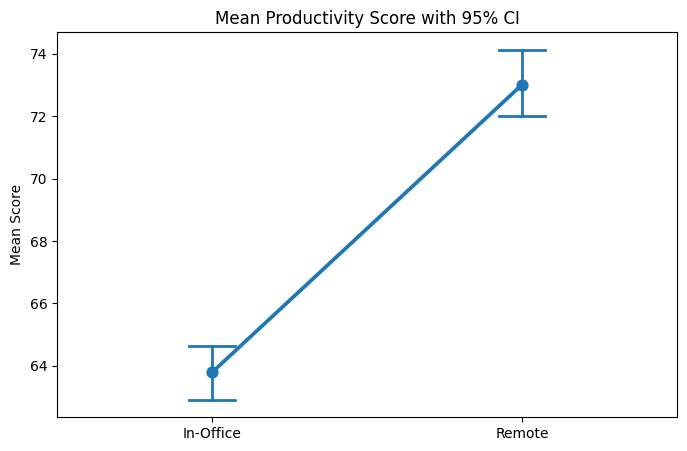

In [27]:
plt.figure(figsize=(8,5))
sns.pointplot(data=df[df['Employment_Type'].isin(['Remote','In-Office'])],
              x='Employment_Type',
              y='Productivity_Score',
              capsize=.15,
              errwidth=2)
plt.title('Mean Productivity Score with 95% CI')
plt.xlabel('')
plt.ylabel('Mean Score')
plt.show()


This graph is showing that remote workers have a higher mean productivity score.

- In-office: 63.8
- Remote: 73

This is a large difference, about 9-10 points.

Confidence intervals do not overlap much

- In-office CI: roughly 63-65
- Remote CI: roughly 72-74

Minimal or no overlap suggests the difference is likely statistically significant.

# Task
Perform a one-way ANOVA test to compare 'Productivity_Score' across 'Hybrid', 'In-Office', and 'Remote' employment types. If significant differences are found, conduct a Tukey HSD post-hoc test. Visualize the ANOVA results with an appropriate plot, and then summarize the statistical findings and their practical implications.

## Perform ANOVA Test

### Subtask:
Conduct a one-way ANOVA test to determine if there are significant differences in 'Productivity_Score' across the 'Hybrid', 'In-Office', and 'Remote' employment types. This will involve extracting productivity scores for each group.


**Reasoning**:
First, I need to extract the 'Productivity_Score' for each employment type (Hybrid, In-Office, Remote) into separate variables to prepare for the ANOVA test, as per the instructions.



In [28]:
hybrid_productivity = df.loc[df['Employment_Type'] == 'Hybrid', 'Productivity_Score']
in_office_productivity = df.loc[df['Employment_Type'] == 'In-Office', 'Productivity_Score']
remote_productivity = df.loc[df['Employment_Type'] == 'Remote', 'Productivity_Score']

print("Hybrid Productivity Scores (first 5):\n", hybrid_productivity.head())
print("\nIn-Office Productivity Scores (first 5):\n", in_office_productivity.head())
print("\nRemote Productivity Scores (first 5):\n", remote_productivity.head())

Hybrid Productivity Scores (first 5):
 0     75
2     74
19    83
35    80
54    74
Name: Productivity_Score, dtype: int64

In-Office Productivity Scores (first 5):
 1     49
5     66
9     59
14    76
16    73
Name: Productivity_Score, dtype: int64

Remote Productivity Scores (first 5):
 3    81
4    70
6    44
7    72
8    70
Name: Productivity_Score, dtype: int64


**Reasoning**:
Now that the productivity scores for each employment type have been extracted into separate variables, I will perform a one-way ANOVA test using `scipy.stats.f_oneway` to determine if there are significant differences across the groups. I will then print the F-statistic and the p-value.



In [29]:
from scipy.stats import f_oneway

f_statistic, p_value = f_oneway(hybrid_productivity, in_office_productivity, remote_productivity)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3e}")

F-statistic: 87.68
P-value: 9.164e-36


### One-way ANOVA Results

*   **F-statistic:** 87.68
*   **p-value:** 9.164e-36

With a p-value much smaller than the common significance level (alpha = 0.05), we can conclude that there are statistically significant differences in 'Productivity_Score' across the 'Hybrid', 'In-Office', and 'Remote' employment types. This means that at least one group's mean productivity score is significantly different from another's.

**Reasoning**:
Since the ANOVA test indicated a significant overall difference, a Tukey HSD post-hoc test is required to identify which specific employment type pairs have significantly different productivity scores. The `pairwise_tukeyhsd` function requires the data in a specific format.



In [30]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Prepare data for Tukey HSD
# The data is already in the 'df' DataFrame, so we just need to specify the columns.

# Perform Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['Productivity_Score'], groups=df['Employment_Type'], alpha=0.05)

print(tukey_result)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
   Hybrid In-Office  -7.5591    0.0 -10.4637 -4.6544   True
   Hybrid    Remote   1.6589 0.3888  -1.3092  4.6269  False
In-Office    Remote   9.2179    0.0   7.5413 10.8945   True
-----------------------------------------------------------


**Reasoning**:
To visualize the differences in 'Productivity_Score' across 'Hybrid', 'In-Office', and 'Remote' employment types, I will create a point plot that shows the mean productivity score for each group along with their confidence intervals, as this is an appropriate visualization for ANOVA results.



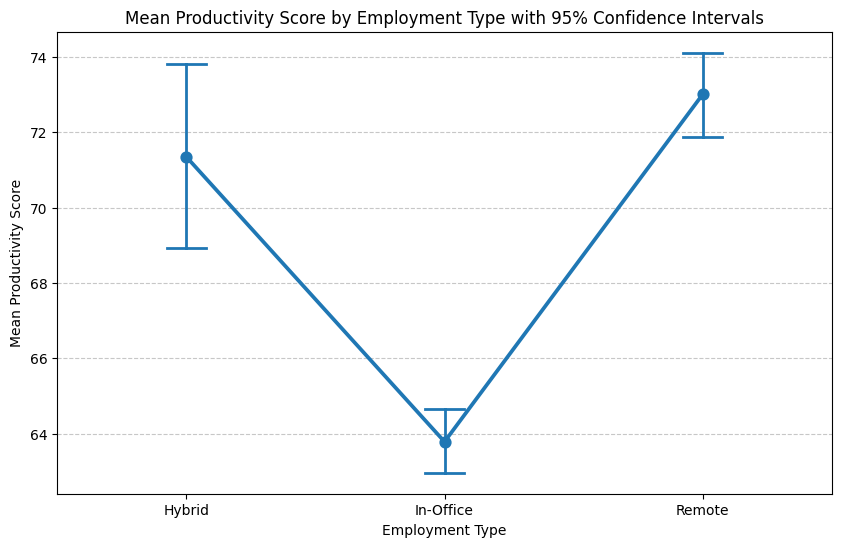

In [32]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='Employment_Type', y='Productivity_Score', capsize=.15, err_kws={'linewidth': 2})
plt.title('Mean Productivity Score by Employment Type with 95% Confidence Intervals')
plt.xlabel('Employment Type')
plt.ylabel('Mean Productivity Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Summary of Statistical Findings and Practical Implications

**One-way ANOVA Test Results:**
*   **F-statistic:** 87.68
*   **p-value:** 9.164e-36

Since the p-value (9.164e-36) is significantly less than the conventional alpha level of 0.05, we reject the null hypothesis. This indicates that there is a statistically significant difference in mean 'Productivity_Score' among the 'Hybrid', 'In-Office', and 'Remote' employment types.

**Tukey HSD Post-Hoc Test Results:**
To determine which specific groups differ, a Tukey HSD post-hoc test was conducted:

*   **Hybrid vs. In-Office:** Mean difference = -7.56, p-adj = 0.000, reject = True
    *   **Interpretation:** In-Office employees have significantly lower productivity scores compared to Hybrid employees.

*   **Hybrid vs. Remote:** Mean difference = 1.66, p-adj = 0.389, reject = False
    *   **Interpretation:** There is no statistically significant difference in productivity scores between Hybrid and Remote employees.

*   **In-Office vs. Remote:** Mean difference = 9.22, p-adj = 0.000, reject = True
    *   **Interpretation:** Remote employees have significantly higher productivity scores compared to In-Office employees.

**Visual Interpretation (Point Plot):**
The point plot visually supports these findings:
*   The mean productivity score for 'Remote' employees is the highest, followed closely by 'Hybrid' employees.
*   The mean productivity score for 'In-Office' employees is noticeably lower than both 'Remote' and 'Hybrid' employees.
*   The 95% confidence intervals for 'Remote' and 'Hybrid' overlap, suggesting no significant difference between them, which aligns with the Tukey HSD result.
*   The confidence interval for 'In-Office' employees does not overlap with either 'Remote' or 'Hybrid' employees, further emphasizing the significant differences.

**Practical Implications:**

1.  **Productivity Advantage in Remote/Hybrid Models:** Both remote and hybrid work models appear to be associated with higher productivity scores compared to traditional in-office work. This suggests that offering flexibility in work location could lead to a more productive workforce.

2.  **Rethinking In-Office Strategies:** Organizations with predominantly in-office work models might need to investigate factors contributing to lower productivity among these employees. This could involve examining office environment, commute stress, collaboration tools, or management practices.

3.  **No Clear Advantage Between Remote and Hybrid:** For productivity, there isn't a statistically significant difference between fully remote and hybrid models. This implies that organizations can choose between these two flexible models based on other factors like collaboration needs, company culture, or employee well-being, without necessarily sacrificing productivity.

These findings provide strong evidence that employment type plays a significant role in employee productivity, with remote and hybrid models showing a clear advantage over traditional in-office arrangements in this dataset.

## Final Task

### Subtask:
Summarize the findings from the ANOVA test and post-hoc analysis, interpreting the statistical significance and practical implications of the results regarding 'Productivity_Score' across different employment types.


## Summary:

### Q&A
The ANOVA test and post-hoc analysis revealed statistically significant differences in 'Productivity\_Score' across employment types. Specifically, 'Remote' and 'Hybrid' employees exhibit significantly higher productivity scores compared to 'In-Office' employees. There is no statistically significant difference in productivity between 'Remote' and 'Hybrid' employment types.

### Data Analysis Key Findings
*   A one-way ANOVA test (F-statistic: 87.68, p-value: 9.164e-36) indicated a statistically significant difference in 'Productivity\_Score' among 'Hybrid', 'In-Office', and 'Remote' employment types.
*   Tukey HSD post-hoc analysis showed:
    *   'In-Office' employees have significantly lower productivity scores compared to 'Hybrid' employees (mean difference = -7.56, p-adjusted = 0.000).
    *   'Remote' employees have significantly higher productivity scores compared to 'In-Office' employees (mean difference = 9.22, p-adjusted = 0.000).
    *   There is no statistically significant difference in productivity between 'Hybrid' and 'Remote' employees (mean difference = 1.66, p-adjusted = 0.389).
*   A point plot visually confirmed that the mean productivity score for 'In-Office' employees is noticeably lower than both 'Remote' and 'Hybrid' employees, while the confidence intervals for 'Remote' and 'Hybrid' overlap.

### Insights or Next Steps
*   Organizations should consider promoting or expanding remote and hybrid work models, as they are associated with higher productivity scores compared to traditional in-office work.
*   Further investigation is warranted into the factors contributing to lower productivity among in-office employees to identify potential areas for improvement in their work environment or practices.
